In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/leehyunji0116/unet-trained/unet.pth
/kaggle/input/competitions/amia-public-challenge-2026/sample_submission.csv
/kaggle/input/competitions/amia-public-challenge-2026/img_size.csv
/kaggle/input/competitions/amia-public-challenge-2026/train.csv
/kaggle/input/competitions/amia-public-challenge-2026/test.csv
/kaggle/input/competitions/amia-public-challenge-2026/test/test/MVPTnneogEY9HeghyRZ79B06zwbCXFb2.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/IPWtMk9UQm8WrDnexcxKPjb7pjbJH2fU.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/2ChzCiewt7Qv6V7PwpxHHNuEPzhV2zmt.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/g122exB2uiXm869vDsaKJVfutXVuRg0U.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/YHLcz1PmUvCnNyxGVwaj7QzfIUWW6UBE.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/e3l2DM0Ht466QyfnJKfXUL1CaoRTmXgN.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/t

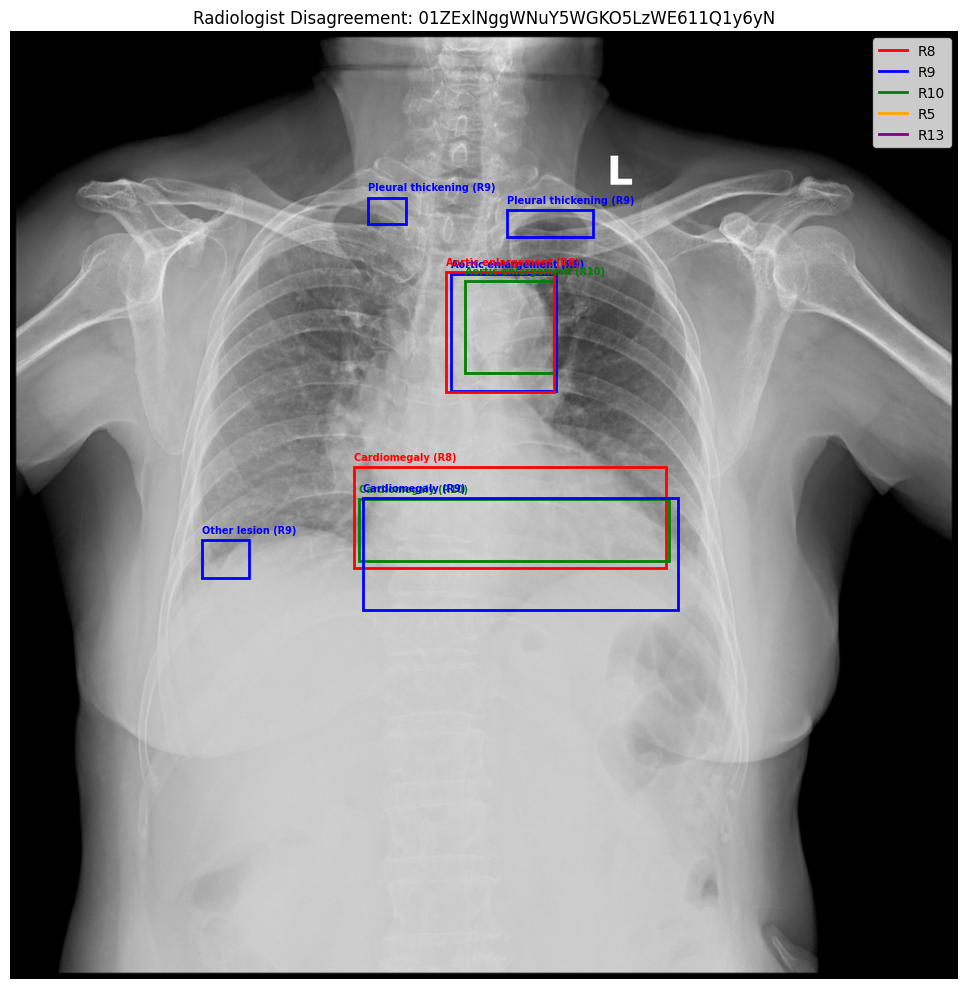

In [ ]:
# EDA - some plots
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

CLASS_NAMES = ['Aortic enlargement','Atelectasis','Calcification','Cardiomegaly',
               'Consolidation','ILD','Infiltration','Lung Opacity','Nodule/Mass',
               'Other lesion','Pleural effusion','Pleural thickening',
               'Pneumothorax','Pulmonary fibrosis']

# radiologist color mapping
RAD_COLORS = {'R8': 'red', 'R9': 'blue', 'R10': 'green',
              'R5': 'orange', 'R13': 'purple'}

def visualize_radiologist_disagreement(image_id, df, img_dir):
    img_path = os.path.join(img_dir, f'{image_id}.png')
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (1024, 1024))

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image, cmap='gray')

    rows = df[(df['image_id'] == image_id) & (df['class_id'] != 14)]
    for _, row in rows.iterrows():
        if pd.isna(row['x_min']):
            continue
        color = RAD_COLORS.get(row['rad_id'], 'yellow')
        x, y = row['x_min'], row['y_min']
        w = row['x_max'] - row['x_min']
        h = row['y_max'] - row['y_min']
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                  edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-8, f"{CLASS_NAMES[int(row['class_id'])]} ({row['rad_id']})",
                color=color, fontsize=7, fontweight='bold')

    # legend
    for rad, color in RAD_COLORS.items():
        ax.plot([], [], color=color, label=rad, linewidth=2)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(f'Radiologist Disagreement: {image_id}', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/viz_disagreement_{image_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

# find a good example image with multiple radiologists and findings
sample_ids = train[train['class_id'] != 14].groupby('image_id')['rad_id'].nunique()
sample_ids = sample_ids[sample_ids >= 2].index.tolist()
visualize_radiologist_disagreement(sample_ids[0], train, TRAIN_IMG_DIR)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

train = pd.read_csv('/kaggle/input/competitions/amia-public-challenge-2026/train.csv')
print(train.shape)
print(train.head())
print(train['class_name'].value_counts())

(45925, 8)
                           image_id          class_name  class_id rad_id  \
0  bM8C97htulC9fHKIDurJHquCXr1KZuug          No finding        14     R5   
1  0FDQVdLgDKI1sRnPL94LzVh9EvXDVM9m  Aortic enlargement         0    R10   
2  Dwk2TnGJFaMhyi3OfCrhdZG9ppGglC5w       Consolidation         4     R8   
3  vqw6mWifHgCf8jmTotrMAS3qCk5eJuc4          No finding        14    R13   
4  EzfCkMwi4E5bAtZZo4brqt9dNbm7sF9z          No finding        14     R5   

    x_min  y_min   x_max   y_max  
0     NaN    NaN     NaN     NaN  
1  1148.0  503.0  1466.0   823.0  
2   264.0  732.0   550.0  1119.0  
3     NaN    NaN     NaN     NaN  
4     NaN    NaN     NaN     NaN  
class_name
No finding            15525
Aortic enlargement     5481
Pleural thickening     4308
Pulmonary fibrosis     4097
Cardiomegaly           4046
Nodule/Mass            2324
Pleural effusion       2190
Lung Opacity           2188
Other lesion           1945
Infiltration           1097
ILD                     904
Cal

* No finding 33%
* Pneumothrax 195, Atelectasis 255
* No finding NaN preprocessing
* rad_id : multiple radiologists saw same image / .consensus / how do we preprocess the disagreement between radiologists?

In [9]:
# how many radiologists per image
print(train.groupby('image_id')['rad_id'].nunique().value_counts())

# how many classes per image
print(train.groupby('image_id')['class_name'].nunique().describe())

# no finding image count
no_finding_imgs = train[train['class_name']=='No finding']['image_id'].nunique()
total_imgs = train['image_id'].nunique()
print(f"Total images: {total_imgs}")
print(f"No finding images: {no_finding_imgs}")

rad_id
3    8573
Name: count, dtype: int64
count    8573.000000
mean        2.088300
std         1.730776
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        10.000000
Name: class_name, dtype: float64
Total images: 8573
No finding images: 5175


In [5]:
# check disagreement between radiologists
sample_id = train[train['class_name'] != 'No finding']['image_id'].iloc[0]
print(train[train['image_id'] == sample_id][['rad_id', 'class_name', 'x_min', 'y_min', 'x_max', 'y_max']])

      rad_id          class_name   x_min   y_min   x_max   y_max
1        R10  Aortic enlargement  1148.0   503.0  1466.0   823.0
3870      R9        Cardiomegaly   791.0  1285.0  1919.0  1617.0
20371     R8  Aortic enlargement  1173.0   489.0  1460.0   829.0
22991     R8        Cardiomegaly   777.0  1172.0  1911.0  1617.0
25191     R9  Aortic enlargement  1186.0   539.0  1461.0   837.0
30520    R10        Cardiomegaly   789.0  1432.0  1925.0  1703.0


* Boxes are different : 중복학습
* solutions
* use all 3 boxes?
* average them?
* WBS : Weighted Box Fusion

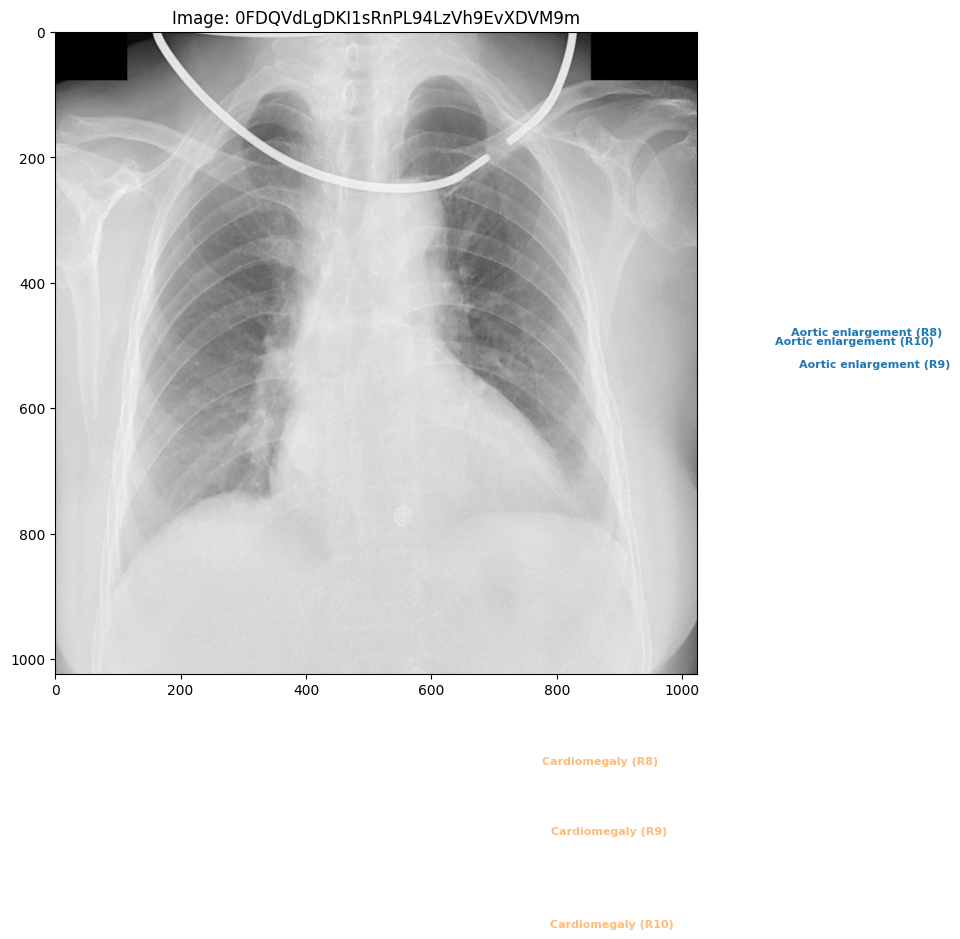

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

def visualize_image(image_id, df):
    img_path = f'/kaggle/input/competitions/amia-public-challenge-2026/train/train/{image_id}.png'
    img = Image.open(img_path)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img, cmap='gray')
    
    rows = df[df['image_id'] == image_id]
    
    colors = plt.cm.tab20.colors
    class_ids = rows['class_id'].unique()
    
    for _, row in rows.iterrows():
        if pd.isna(row['x_min']):
            continue
        x, y = row['x_min'], row['y_min']
        w = row['x_max'] - row['x_min']
        h = row['y_max'] - row['y_min']
        color = colors[int(row['class_id']) % len(colors)]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, f"{row['class_name']} ({row['rad_id']})", 
                color=color, fontsize=8, fontweight='bold')
    
    ax.set_title(f'Image: {image_id}')
    plt.tight_layout()
    plt.show()

# visualize the sample image from before
sample_id = train[train['class_name'] != 'No finding']['image_id'].iloc[0]
visualize_image(sample_id, train)

In [13]:
img_size = pd.read_csv('/kaggle/input/competitions/amia-public-challenge-2026/img_size.csv')
print(img_size.head())
print(img_size.describe())

                           image_id  dim0  dim1
0  j8ucb4pF6s210AWzYbWtWDjkHDfEIvqh  3000  3000
1  QX1b3KBwsnmxGJzmdUwwH0IeQtNlvYAU  3072  3072
2  kXObj3UtUTmZDgpBy3UdxAi2hef5ODEx  2836  2336
3  byLdYlU27P9zWLSYefZjEVRYBZPuwIW2  2952  2744
4  hTBiatGXktRwkGmEKdsLu7QSUYaH8XBa  2880  2304
               dim0          dim1
count  15000.000000  15000.000000
mean    2786.866600   2446.286933
std      301.100076    366.247726
min      927.000000    823.000000
25%     2500.000000   2048.000000
50%     2847.000000   2388.000000
75%     3051.000000   2670.000000
max     3408.000000   3320.000000


In [16]:
# merge img_size into train
train = train.merge(img_size, on='image_id', how='left')

# scale bounding boxes to 1024x1024
train['x_min_scaled'] = train['x_min'] / train['dim1'] * 1024
train['x_max_scaled'] = train['x_max'] / train['dim1'] * 1024
train['y_min_scaled'] = train['y_min'] / train['dim0'] * 1024
train['y_max_scaled'] = train['y_max'] / train['dim0'] * 1024

print(train[['x_min', 'x_min_scaled', 'x_max', 'x_max_scaled']].head(10))

    x_min  x_min_scaled   x_max  x_max_scaled
0     NaN           NaN     NaN           NaN
1  1148.0    489.405495  1466.0    624.972523
2   264.0    130.471042   550.0    271.814672
3     NaN           NaN     NaN           NaN
4     NaN           NaN     NaN           NaN
5  1624.0    624.240240  1741.0    669.213213
6     NaN           NaN     NaN           NaN
7   786.0    393.000000  1618.0    809.000000
8  1594.0    708.444444  1743.0    774.666667
9     NaN           NaN     NaN           NaN


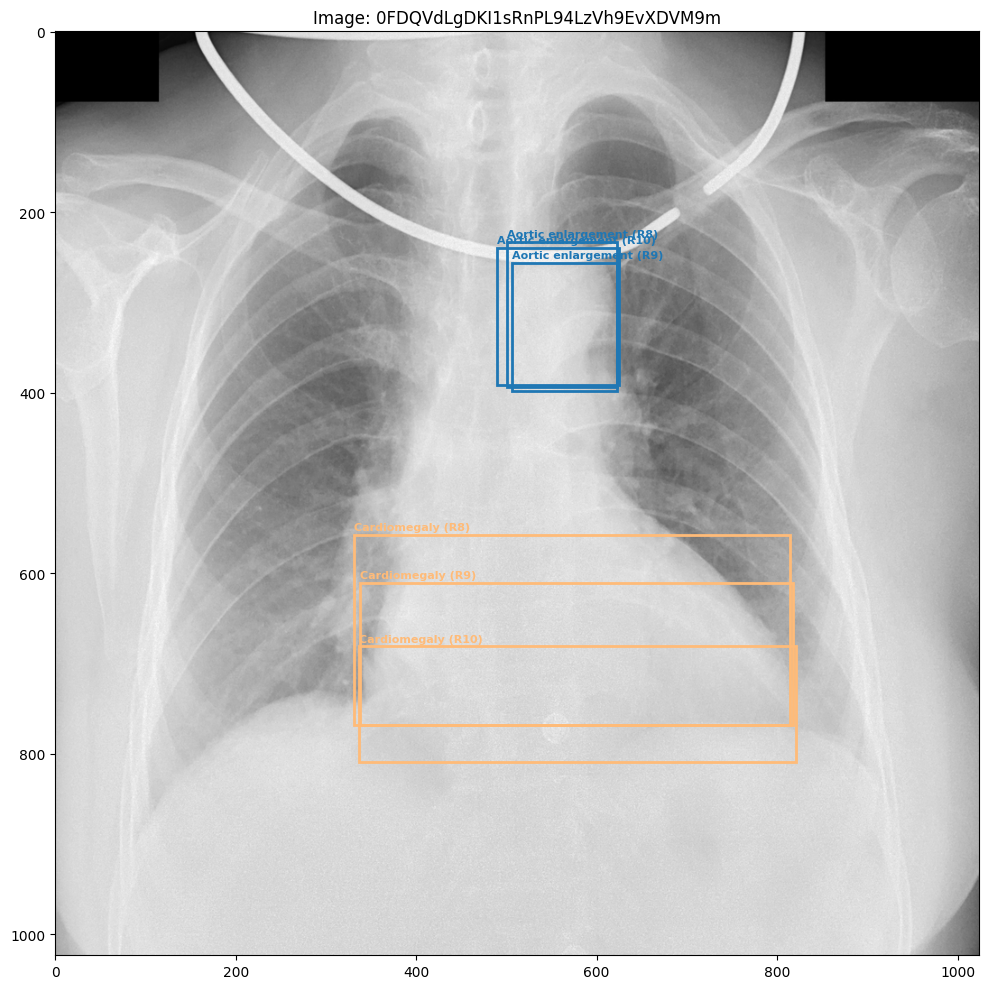

In [17]:
# edited
def visualize_image(image_id, df):
    img_path = f'/kaggle/input/competitions/amia-public-challenge-2026/train/train/{image_id}.png'
    img = Image.open(img_path)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img, cmap='gray')
    
    rows = df[df['image_id'] == image_id]
    colors = plt.cm.tab20.colors
    
    for _, row in rows.iterrows():
        if pd.isna(row['x_min_scaled']):
            continue
        x, y = row['x_min_scaled'], row['y_min_scaled']
        w = row['x_max_scaled'] - row['x_min_scaled']
        h = row['y_max_scaled'] - row['y_min_scaled']
        color = colors[int(row['class_id']) % len(colors)]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, f"{row['class_name']} ({row['rad_id']})",
                color=color, fontsize=8, fontweight='bold')
    
    ax.set_title(f'Image: {image_id}')
    plt.tight_layout()
    plt.show()

visualize_image(sample_id, train)

/tmp/ipykernel_58/2188369766.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')


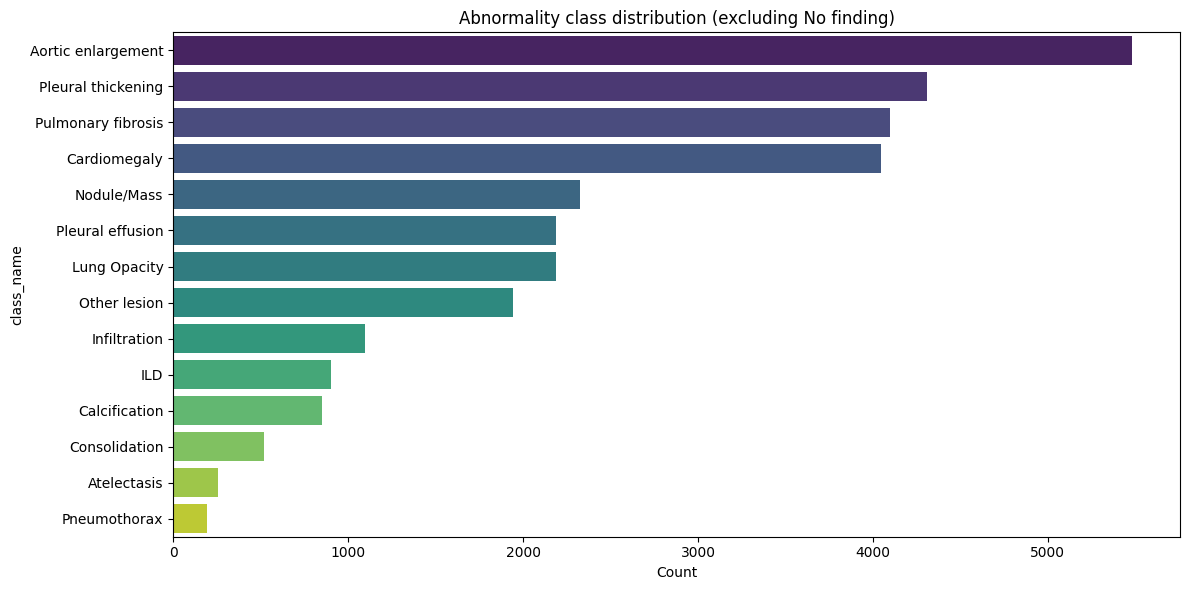

In [18]:
import seaborn as sns

class_counts = train[train['class_name'] != 'No finding']['class_name'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, palette='viridis')
plt.xlabel('Count')
plt.title('Abnormality class distribution (excluding No finding)')
plt.tight_layout()
plt.show()

Long-tail distribution

Aortic enlargement: ~5,500
Pneumothorax: ~195

Class imbalance : Focal Loss → RetinaNet ?
Rare class: Oversampling or weighted loss
Multi-radiologist: WBF (Weighted Box Fusion) ?

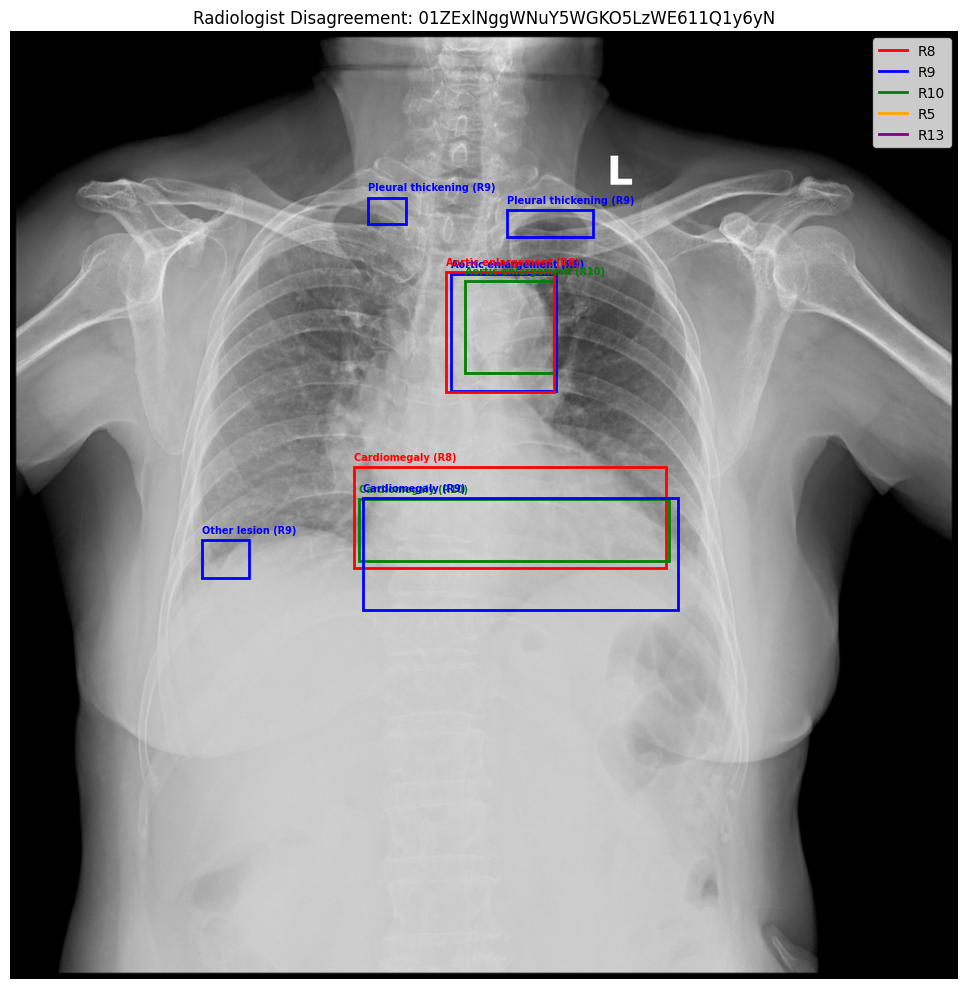

In [ ]:
# some plots for report
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

CLASS_NAMES = ['Aortic enlargement','Atelectasis','Calcification','Cardiomegaly',
               'Consolidation','ILD','Infiltration','Lung Opacity','Nodule/Mass',
               'Other lesion','Pleural effusion','Pleural thickening',
               'Pneumothorax','Pulmonary fibrosis']

# radiologist color mapping
RAD_COLORS = {'R8': 'red', 'R9': 'blue', 'R10': 'green',
              'R5': 'orange', 'R13': 'purple'}

def visualize_radiologist_disagreement(image_id, df, img_dir):
    img_path = os.path.join(img_dir, f'{image_id}.png')
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (1024, 1024))

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image, cmap='gray')

    rows = df[(df['image_id'] == image_id) & (df['class_id'] != 14)]
    for _, row in rows.iterrows():
        if pd.isna(row['x_min']):
            continue
        color = RAD_COLORS.get(row['rad_id'], 'yellow')
        x, y = row['x_min'], row['y_min']
        w = row['x_max'] - row['x_min']
        h = row['y_max'] - row['y_min']
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                  edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-8, f"{CLASS_NAMES[int(row['class_id'])]} ({row['rad_id']})",
                color=color, fontsize=7, fontweight='bold')

    # legend
    for rad, color in RAD_COLORS.items():
        ax.plot([], [], color=color, label=rad, linewidth=2)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(f'Radiologist Disagreement: {image_id}', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/viz_disagreement_{image_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

# find a good example image with multiple radiologists and findings
sample_ids = train[train['class_id'] != 14].groupby('image_id')['rad_id'].nunique()
sample_ids = sample_ids[sample_ids >= 2].index.tolist()
visualize_radiologist_disagreement(sample_ids[0], train, TRAIN_IMG_DIR)